In [24]:
"""
Predictive Maintenance Pipeline – Compact Report Version
Dataset: AI4I 2020 (XGBoost + SMOTE)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            roc_curve)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")


In [38]:
# ==================== Load & Clean ====================
df = pd.read_csv("predictive_maintenance.csv")
df.drop(['UDI', 'Product ID', 'Failure Type'], axis=1, errors='ignore', inplace=True)
df['ProductType'] = df['Product ID'].str[0].map({'L':0,'M':1,'H':2}) if 'Product ID' in df.columns else 0
df.drop('Product ID', axis=1, errors='ignore', inplace=True)


# Feature engineering
df['TempDiff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]'] / 9550
df['Stress'] = df['Torque [Nm]'] * df['Tool wear [min]']
df['RPM_Squared'] = df['Rotational speed [rpm]'] ** 2

# Features & target
X = df.select_dtypes(include=[np.number]).drop('Machine failure', axis=1)
y = df['Machine failure']
print(f"Features: {list(X.columns)}")
print(f"Failure rate: {y.mean()*100:.2f}%")

Features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'ProductType', 'TempDiff', 'Power', 'Stress', 'RPM_Squared']
Failure rate: 3.39%


In [26]:

# ==================== Train/Test & SMOTE ====================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)


In [27]:

# ==================== Train XGBoost ====================
model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8, random_state=42,
                          eval_metric='logloss', use_label_encoder=False)
model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [28]:

# ==================== Evaluation ====================
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"\nAccuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")



Accuracy: 0.9990 | Precision: 1.0000 | Recall: 0.9706 | F1: 0.9851 | AUC: 0.9880


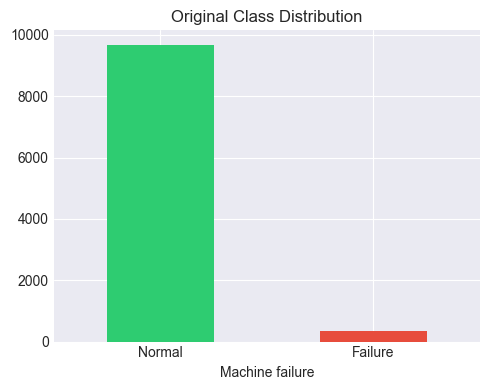

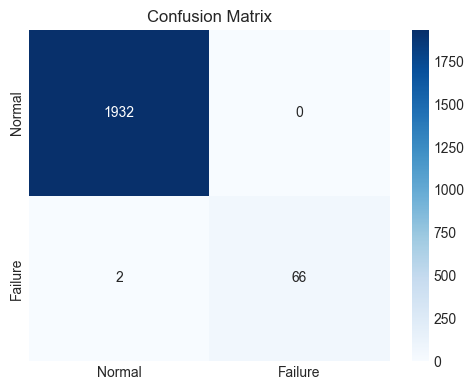

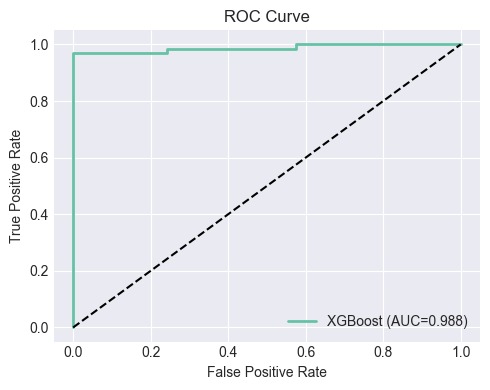

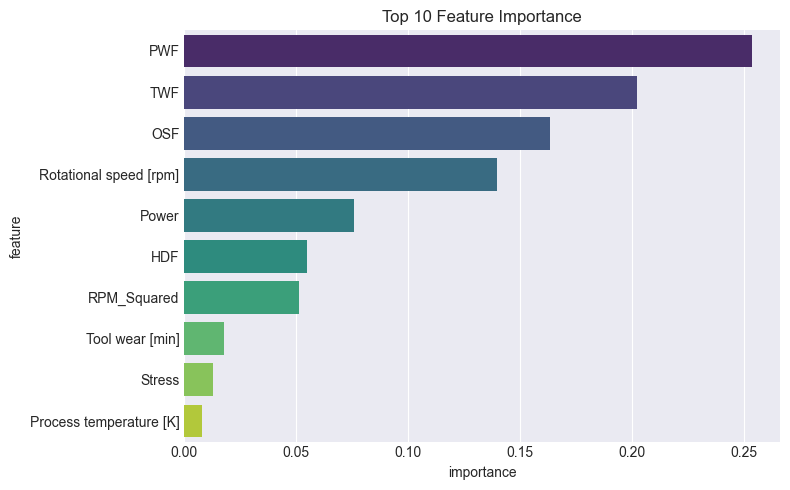


Top 3 features: ['PWF', 'TWF', 'OSF']


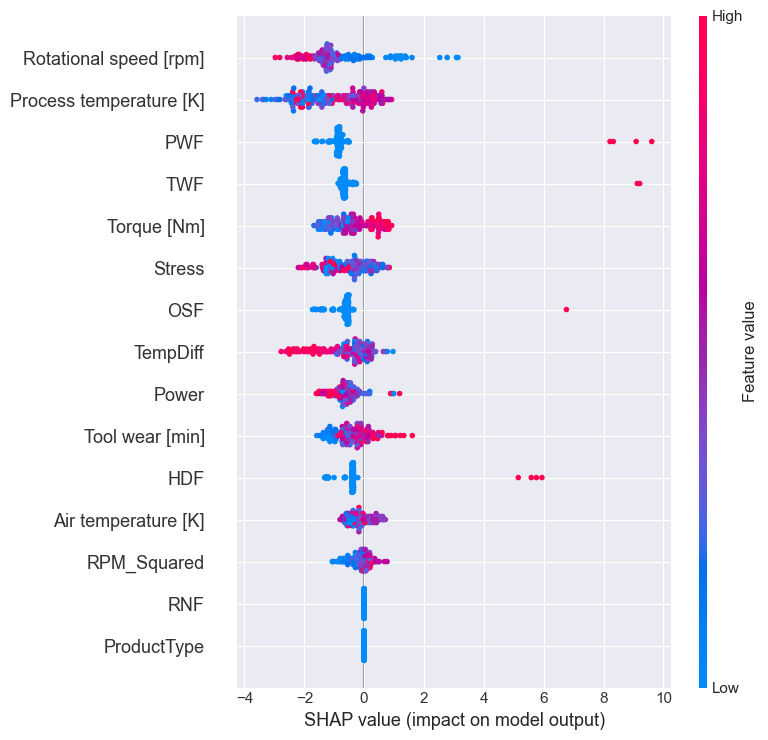

In [29]:

# ==================== Graphs ====================

# Graph : Class distribution (original)
plt.figure(figsize=(5,4))
df['Machine failure'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'])
plt.title('Original Class Distribution', fontsize=12)
plt.xticks([0,1],['Normal','Failure'], rotation=0)
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=120)
plt.show()

# Graph : Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal','Failure'], yticklabels=['Normal','Failure'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('02_confusion_matrix.png', dpi=120)
plt.show()

# Graph : ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc:.3f})', linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('03_roc_curve.png', dpi=120)
plt.show()

# Graph : Top 10 Feature Importance
importance = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance.head(10), y='feature', x='importance', palette='viridis')
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=120)
plt.show()
print("\nTop 3 features:", importance.head(3)['feature'].tolist())



# Graph: SHAP Summary (compact)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled[:200])
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns, show=False)
plt.tight_layout()
plt.savefig('05_shap_summary.png', dpi=120)
plt.show()

In [30]:
#  Maintenance Thresholds 
fail_probs = y_proba[y_test == 1]
if len(fail_probs) > 0:
    q25, q50, q75 = np.percentile(fail_probs, [25,50,75])
    print(f"\nMaintenance thresholds: Normal<{q25:.3f} | Caution {q25:.3f}-{q50:.3f} | Warning {q50:.3f}-{q75:.3f} | Critical>{q75:.3f}")


Maintenance thresholds: Normal<0.999 | Caution 0.999-0.999 | Warning 0.999-1.000 | Critical>1.000


In [31]:
# model 
joblib.dump(model, 'pm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel saved as pm_model.pkl")
print("All 5 graphs saved successfully.")


Model saved as pm_model.pkl
All 5 graphs saved successfully.
